In [5]:
import numpy as np

# --- Configuration ---
N = 512
AMPLITUDE = 100
Q = 16           # 16-bit fixed point

def to_hex_16(val):
    """Converts int/float to 16-bit hex (2's complement)"""
    val = int(val)
    if val > 32767: val = 32767
    if val < -32768: val = -32768
    return f"{(val & 0xFFFF):04x}"

def to_bin_16(val):
    """Converts int/float to 16-bit binary (2's complement)"""
    val = int(val)
    if val > 32767: val = 32767
    if val < -32768: val = -32768
    return f"{(val & 0xFFFF):016b}"

# 1. Generate Input Signal (Square Wave)
x = np.concatenate((
    AMPLITUDE * np.ones(128), 
    -AMPLITUDE * np.ones(128), 
    AMPLITUDE * np.ones(128), 
    -AMPLITUDE * np.ones(128)
))

print(f"Generating test_in_512.memh...")
with open("test_in_512.memh", "w") as f:
    for s in x:
        # CORRECT FORMAT: RRRRIIII (Real in upper 16, Imag in lower 16)
        real_hex = to_hex_16(s.real)
        imag_hex = to_hex_16(0) # Force Imaginary to 0
        f.write(f"{real_hex}{imag_hex}\n")

# 2. Generate Golden Output (FFT)
# Note: Using standard numpy FFT for verification
fft_out = np.fft.fft(x)

print(f"Generating ideal_test_out_512.memh...")
with open("ideal_test_out_512.memh", "w") as f:
    for s in fft_out:
        # Clip to prevent overflow in verification logic
        # (Though your FP-FFT logic in the notebook looked good too)
        real_hex = to_hex_16(s.real)
        imag_hex = to_hex_16(s.imag)
        f.write(f"{real_hex}{imag_hex}\n")

# 3. Generate Twiddle Factors (Your logic was correct, just ensuring filename matches)
print(f"Generating twiddle.vectors...")
k = np.arange(N // 2)
twiddles = np.exp(-1j * 2 * np.pi * k / N)
MAX_SCALAR = 32767 

with open("twiddle.vectors", "w") as f:
    for t in twiddles:
        real_int = int(round(t.real * MAX_SCALAR))
        imag_int = int(round(t.imag * MAX_SCALAR))
        # Format as 32-bit binary for $readmemb
        bin_line = f"{to_bin_16(real_int)}{to_bin_16(imag_int)}"
        f.write(f"{bin_line}\n")

print("Done! Files generated.")

Generating test_in_512.memh...
Generating ideal_test_out_512.memh...
Generating twiddle.vectors...
Done! Files generated.


Maximum Error Magnitude: 18.0000


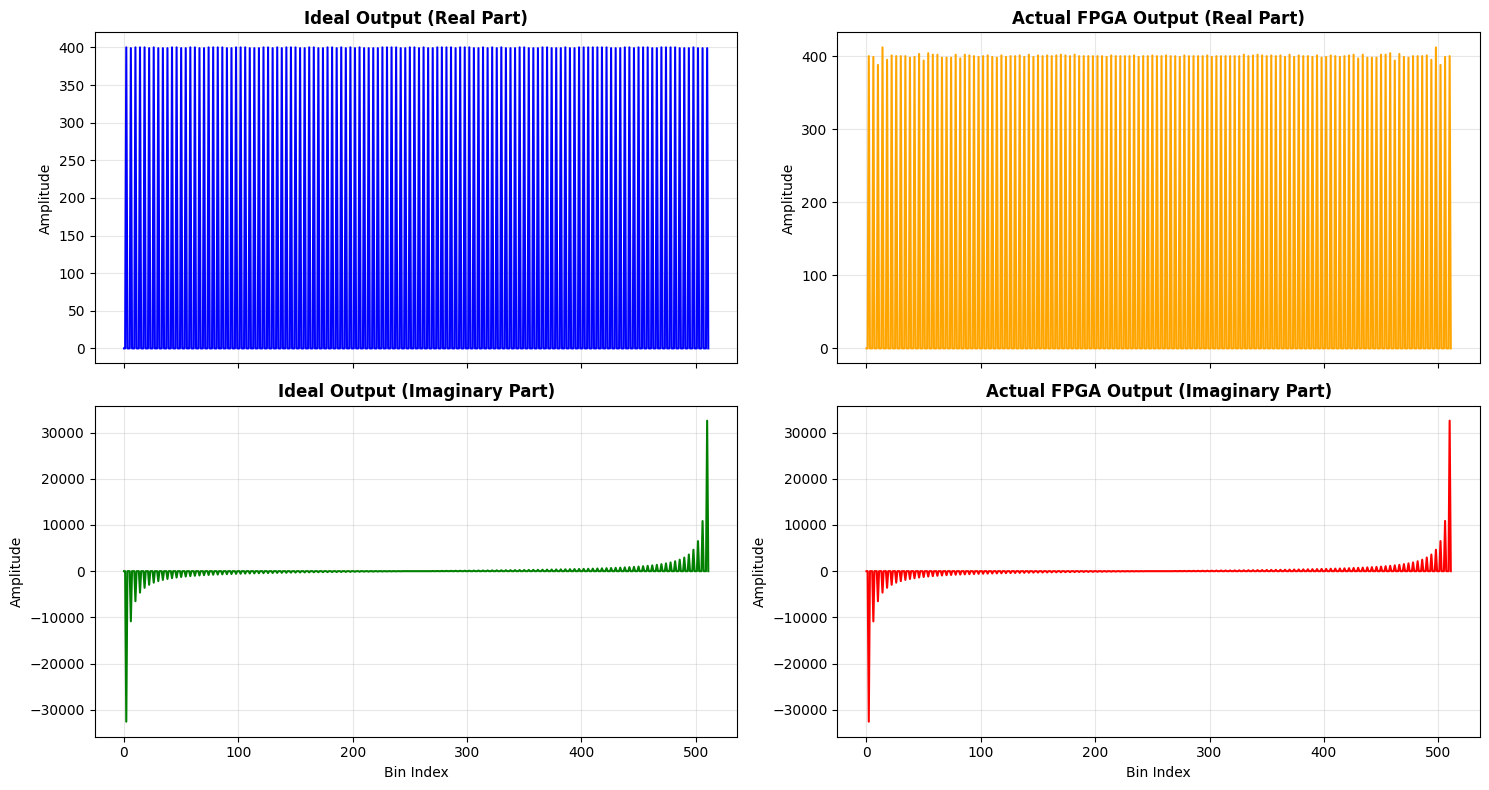

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
IDEAL_FILE = "ideal_test_out_512.memh"
ACTUAL_FILE = "test_out_512.memh"
N = 512

def hex_to_int16(hex_str):
    """Converts 4-char hex string to 16-bit signed integer."""
    val = int(hex_str, 16)
    if val >= 32768:  # 2^15
        val -= 65536  # 2^16
    return val

def load_memh(filename):
    """Parses a .memh file (RRRRIIII hex format) into a complex numpy array."""
    data = []
    try:
        with open(filename, 'r') as f:
            lines = f.readlines()
            for line in lines:
                line = line.strip()
                if not line: continue
                
                # Split 32-bit hex into two 16-bit parts
                # Format: RRRRIIII
                real_hex = line[0:4]
                imag_hex = line[4:8]
                
                re = hex_to_int16(real_hex)
                im = hex_to_int16(imag_hex)
                
                data.append(re + 1j * im)
    except FileNotFoundError:
        print(f"Error: Could not find {filename}. Make sure you run the simulation first!")
        return np.zeros(N, dtype=np.complex128)
        
    return np.array(data)

# --- Main Visualization ---

# 1. Load Data
ideal_data = load_memh(IDEAL_FILE)
actual_data = load_memh(ACTUAL_FILE)

# Ensure data lengths match (pad with zeros if actual is short)
if len(actual_data) < N:
    print(f"Warning: Actual data short ({len(actual_data)}/{N}). Padding.")
    actual_data = np.pad(actual_data, (0, N - len(actual_data)))

# 2. Setup Plotting Grid (2 Rows, 2 Columns)
fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

# --- Real Part Comparison (Top Row) ---
# Ideal Real
axs[0, 0].plot(np.real(ideal_data), color='blue', linewidth=1.5)
axs[0, 0].set_title('Ideal Output (Real Part)', fontweight='bold')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].grid(True, alpha=0.3)

# Actual Real
axs[0, 1].plot(np.real(actual_data), color='orange', linewidth=1.5)
axs[0, 1].set_title('Actual FPGA Output (Real Part)', fontweight='bold')
axs[0, 1].set_ylabel('Amplitude')
axs[0, 1].grid(True, alpha=0.3)

# --- Imaginary Part Comparison (Bottom Row) ---
# Ideal Imaginary
axs[1, 0].plot(np.imag(ideal_data), color='green', linewidth=1.5)
axs[1, 0].set_title('Ideal Output (Imaginary Part)', fontweight='bold')
axs[1, 0].set_ylabel('Amplitude')
axs[1, 0].set_xlabel('Bin Index')
axs[1, 0].grid(True, alpha=0.3)

# Actual Imaginary
axs[1, 1].plot(np.imag(actual_data), color='red', linewidth=1.5)
axs[1, 1].set_title('Actual FPGA Output (Imaginary Part)', fontweight='bold')
axs[1, 1].set_ylabel('Amplitude')
axs[1, 1].set_xlabel('Bin Index')
axs[1, 1].grid(True, alpha=0.3)

# 3. Calculate and Print Error
error = np.abs(ideal_data - actual_data)
max_error = np.max(error)
print(f"Maximum Error Magnitude: {max_error:.4f}")

plt.tight_layout()
plt.show()